In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle

# Load data
df = pd.read_csv("../data/RELIANCE_features_v2.csv", 
                  index_col=0, parse_dates=True)
X_test = pd.read_csv("../data/X_test.csv", 
                      index_col=0, parse_dates=True)
y_test = pd.read_csv("../data/y_test.csv", 
                      index_col=0, parse_dates=True).squeeze()

with open("../data/model.pkl", "rb") as f:
    model = pickle.load(f)

# Set a clean style for all plots
plt.style.use("seaborn-v0_8-darkgrid")
SAVE_PATH = "../results/plots/"

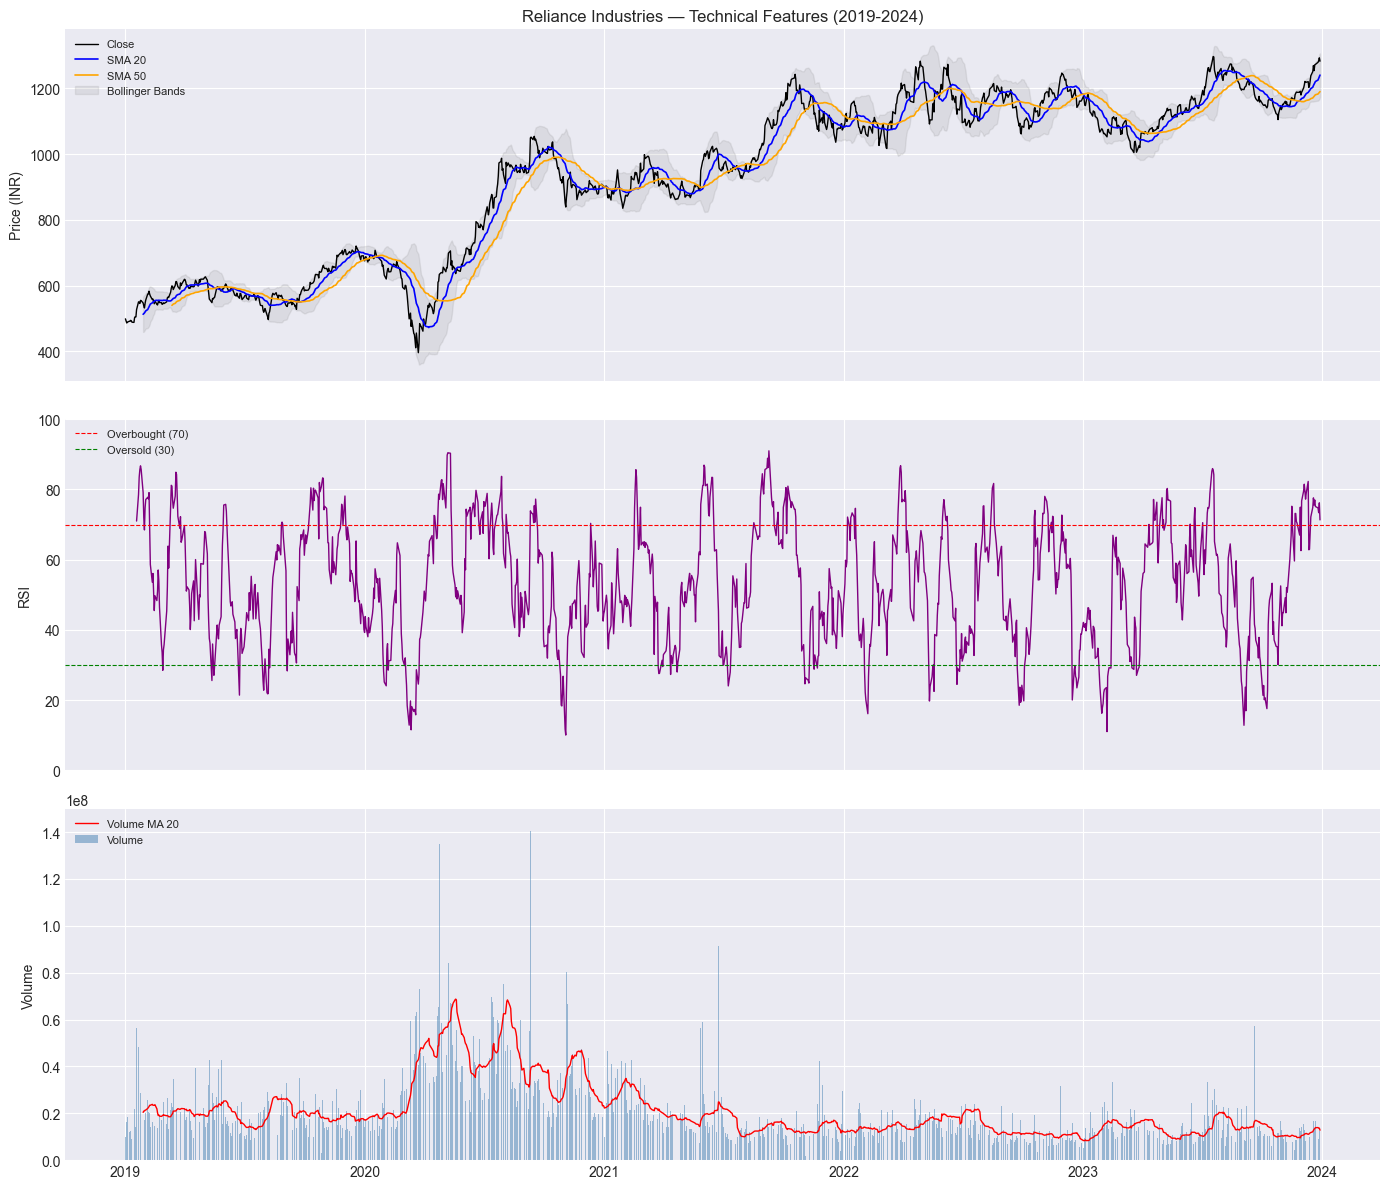

Plot 1 saved


In [2]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1 - Price and moving averages
axes[0].plot(df["Close"], label="Close", linewidth=1, color="black")
axes[0].plot(df["SMA_20"], label="SMA 20", linewidth=1.2, color="blue")
axes[0].plot(df["SMA_50"], label="SMA 50", linewidth=1.2, color="orange")
axes[0].fill_between(df.index, df["BB_Upper"], df["BB_Lower"], 
                      alpha=0.15, color="grey", label="Bollinger Bands")
axes[0].set_ylabel("Price (INR)")
axes[0].set_title("Reliance Industries — Technical Features (2019-2024)")
axes[0].legend(loc="upper left", fontsize=8)

# Panel 2 - RSI
axes[1].plot(df["RSI_14"], color="purple", linewidth=1)
axes[1].axhline(70, color="red", linestyle="--", linewidth=0.8, label="Overbought (70)")
axes[1].axhline(30, color="green", linestyle="--", linewidth=0.8, label="Oversold (30)")
axes[1].set_ylabel("RSI")
axes[1].set_ylim(0, 100)
axes[1].legend(loc="upper left", fontsize=8)

# Panel 3 - Volume
axes[2].bar(df.index, df["Volume"], color="steelblue", alpha=0.5, label="Volume")
axes[2].plot(df["Volume_MA_20"], color="red", linewidth=1, label="Volume MA 20")
axes[2].set_ylabel("Volume")
axes[2].legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig(SAVE_PATH + "01_technical_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 1 saved")

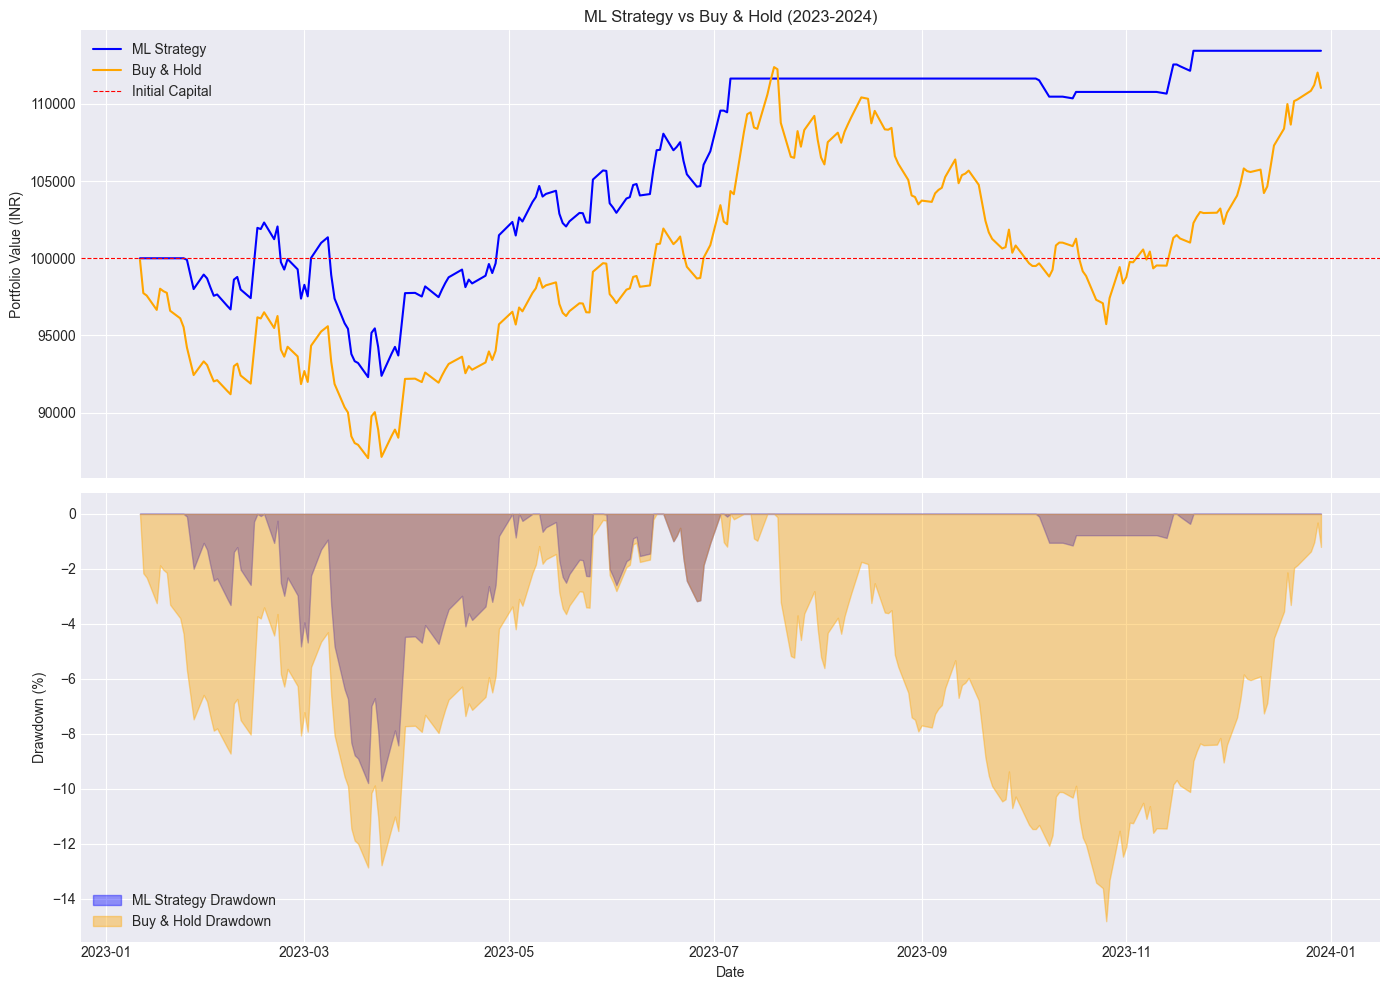

Plot 2 saved


In [7]:
# Regenerate backtest results
from sklearn.preprocessing import MinMaxScaler

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

results = pd.read_csv("../data/results.csv", index_col=0, parse_dates=True)

# Run backtest functions from Day 7
# (paste your backtest_strategy and buy_and_hold functions here)
def buy_and_hold(results,initial_capital=100000, transaction_cost=0.001):
    open_price=results["Close"].iloc[0];
    shares_bought=initial_capital/(open_price*(1+transaction_cost))
    results["BuyHold_Value"]=shares_bought*results["Close"]

    last_price=results["Close"].iloc[-1];
    sell_money=shares_bought*(last_price*(1-transaction_cost))
    
    results.loc[results.index[-1], "BuyHold_Value"]=sell_money

    return results

def backtest_strategy(results, initial_capital=100000, transaction_cost=0.001, threshold=0.5):
    """We are simply doing these steps: 
        -If currently not holding and model predicts UP, we buy
        -If holding and model predicts DOWN, we sell
        -A simple transaction cost on every share bought and sold
        -We have kept the proability threshold to be .5 here
    
    """

    capital= initial_capital
    position=0 # number of shares held
    portfolio=[] #closing value of portfolio each day
    cash=[]
    stock_value=[]
    buy=True    #track if we can buy right now or not


    for i in range(len(results)):

        price=results["Close"].iloc[i]
        prob=results["Probability"].iloc[i]

        if (buy and prob>=threshold):
            shares_bought=capital/(price*(1+transaction_cost))
            capital=0
            position=shares_bought
            buy=False

        elif (not buy and prob<threshold):
            money_got=position*(price*(1-transaction_cost))
            capital=money_got
            position=0
            buy=True

        total_value=position*price+capital
        portfolio.append(total_value)
        cash.append(capital)
        stock_value.append(position*price)
    results["CashInHand"]=cash
    results["Stock_Value"]=stock_value
    results["Strategy_Value"]= portfolio
    return results



results = backtest_strategy(results, initial_capital=100000, 
                             transaction_cost=0.001, threshold=0.5)
results = buy_and_hold(results, initial_capital=100000, 
                        transaction_cost=0.001)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel 1 - Portfolio value
axes[0].plot(results.index, results["Strategy_Value"], 
             label="ML Strategy", color="blue", linewidth=1.5)
axes[0].plot(results.index, results["BuyHold_Value"], 
             label="Buy & Hold", color="orange", linewidth=1.5)
axes[0].axhline(100000, color="red", linestyle="--", 
                linewidth=0.8, label="Initial Capital")
axes[0].set_ylabel("Portfolio Value (INR)")
axes[0].set_title("ML Strategy vs Buy & Hold (2023-2024)")
axes[0].legend()

# Panel 2 - Drawdown
def compute_drawdown(series):
    rolling_max = series.cummax()
    return (series - rolling_max) / rolling_max

axes[1].fill_between(results.index, 
                      compute_drawdown(results["Strategy_Value"]) * 100,
                      0, alpha=0.4, color="blue", label="ML Strategy Drawdown")
axes[1].fill_between(results.index,
                      compute_drawdown(results["BuyHold_Value"]) * 100,
                      0, alpha=0.4, color="orange", label="Buy & Hold Drawdown")
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.savefig(SAVE_PATH + "02_backtest_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 2 saved")

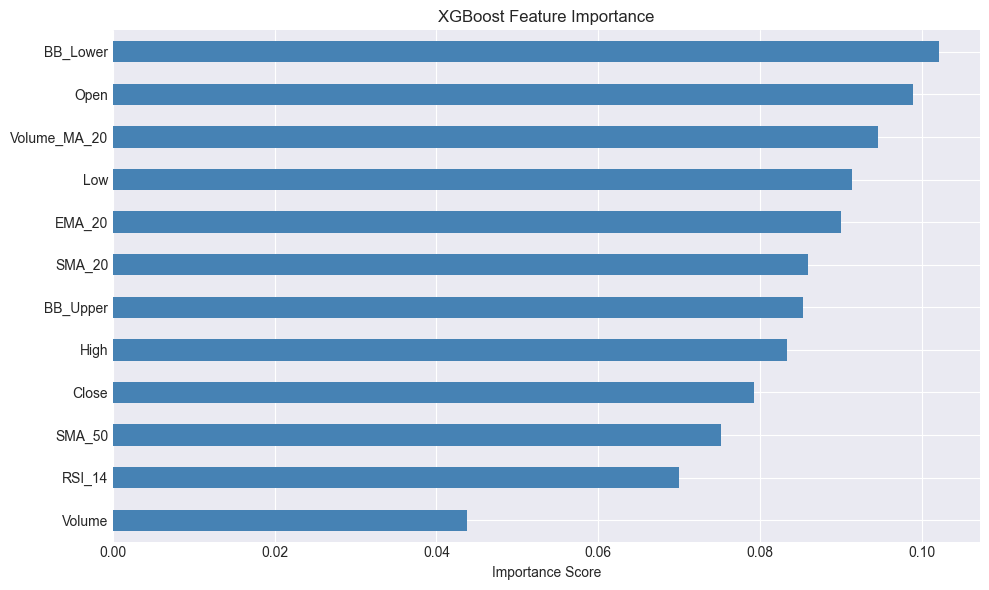

Plot 3 saved


In [4]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X_test.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("XGBoost Feature Importance")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig(SAVE_PATH + "03_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 3 saved")

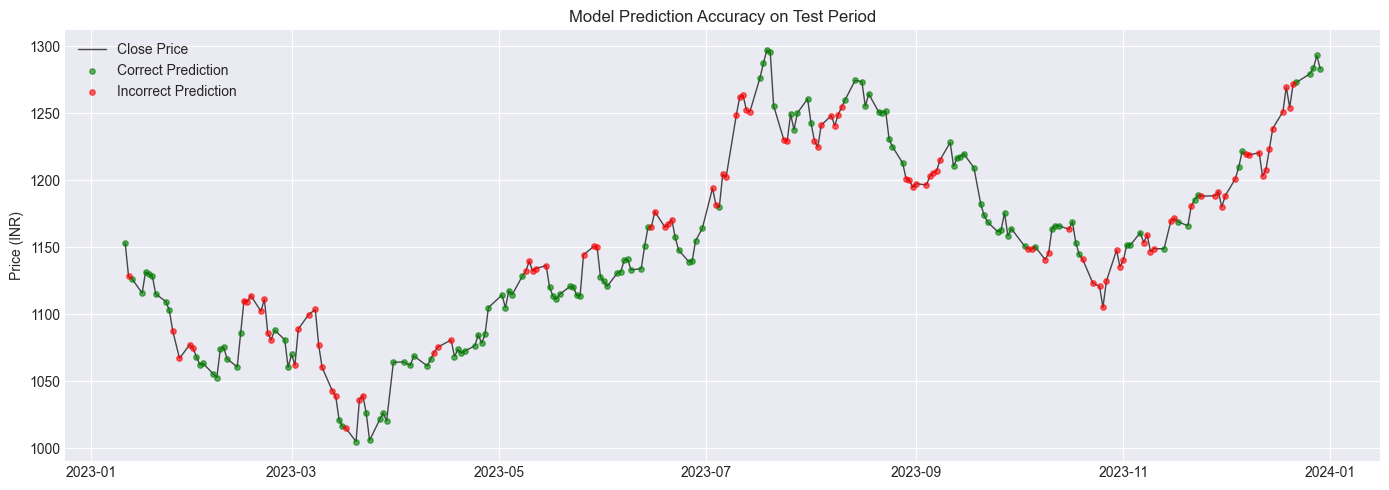

Plot 4 saved


In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(results.index, results["Close"], 
        color="black", linewidth=1, label="Close Price", alpha=0.7)

# Mark correct and incorrect predictions
correct   = results[results["Actual"] == results["Predicted"]]
incorrect = results[results["Actual"] != results["Predicted"]]

ax.scatter(correct.index, correct["Close"], 
           color="green", s=15, label="Correct Prediction", alpha=0.6, zorder=5)
ax.scatter(incorrect.index, incorrect["Close"], 
           color="red", s=15, label="Incorrect Prediction", alpha=0.6, zorder=5)

ax.set_title("Model Prediction Accuracy on Test Period")
ax.set_ylabel("Price (INR)")
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_PATH + "04_prediction_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 4 saved")

In [9]:
strategy_return= (results["Strategy_Value"].iloc[-1]-100000)/100000 * 100
buyhold_return= (results["BuyHold_Value"].iloc[-1]-100000)/100000 *100

def calc_metrics(portfolio_value, label="Stratergy"):
    values=pd.Series(portfolio_value)
    returns=values.pct_change().dropna()


    sharpe=(returns.mean()/returns.std()) * np.sqrt(252)

    rolling_max=values.cummax()
    drawdown=(values-rolling_max)/rolling_max
    max_dd=drawdown.min()

    # print(f"\n{label}:")
    # print(f" Sharpe Ratio: {sharpe:.4f}")
    # print(f" Max_DD: {max_dd*100:.4f}")

    return sharpe, max_dd

strat_sharpe, strat_dd = calc_metrics(
    results["Strategy_Value"], "ML Strategy")
bh_sharpe, bh_dd       = calc_metrics(
    results["BuyHold_Value"], "Buy & Hold")


print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(f"Test Period:          {results.index[0].date()} to {results.index[-1].date()}")
print(f"Initial Capital:      INR 100,000")
print(f"\nML Strategy:")
print(f"  Final Value:        INR {results['Strategy_Value'].iloc[-1]:,.0f}")
print(f"  Total Return:       {strategy_return:.2f}%")
print(f"  Sharpe Ratio:       {strat_sharpe:.4f}")
print(f"  Max Drawdown:       {strat_dd*100:.2f}%")
print(f"\nBuy & Hold:")
print(f"  Final Value:        INR {results['BuyHold_Value'].iloc[-1]:,.0f}")
print(f"  Total Return:       {buyhold_return:.2f}%")
print(f"  Sharpe Ratio:       {bh_sharpe:.4f}")
print(f"  Max Drawdown:       {bh_dd*100:.2f}%")
print("="*50)


FINAL RESULTS SUMMARY
Test Period:          2023-01-11 to 2023-12-29
Initial Capital:      INR 100,000

ML Strategy:
  Final Value:        INR 113,443
  Total Return:       13.44%
  Sharpe Ratio:       1.1205
  Max Drawdown:       -9.79%

Buy & Hold:
  Final Value:        INR 111,034
  Total Return:       11.03%
  Sharpe Ratio:       0.7362
  Max Drawdown:       -14.82%
